In [102]:
import pandas as pd

# Path to your Excel file
file_path = 'species_535.xlsx'

# Load only the first few rows to read column names
data_scfa = pd.read_excel(file_path, nrows=5, index_col=0)

## differet scfa producers, use different 
# Define your species of interest
scfa_species = ["Bacteroides", "Prevotella", "Coprococcus comes", "Veillonella", "Dialister", "Salmonella"]
#["Akkermansia muciniphila", "Bacteroides", "Ruminococcus", "Prevotella", "Escherichia coli", "Fusobacterium",
               #"Lactobacillus"]
               # "Faecalibacterium prausnitzii", "Roseburia", "Anaerostipes caccae", "Butyrivibrio fibrisolvens", "Subdoligranulum variabile",
              # "Anaerotruncus colihominis", "Eubacterium limosum", "Coprococcus"]

# Find columns that contain any of the species names
#filtered_columns = [col for col in data_butyrate.columns if any(species in col for species in butyrate_species)]

filtered_indices = [i for i, col in enumerate(data_scfa.columns, start=1) if any(species in col for species in scfa_species)]

# Include the first column index (0) with the filtered indices
use_columns = [0] + filtered_indices

# Load the entire file with only the filtered columns, setting the first column as the index
propionate_data = pd.read_excel(file_path, usecols=use_columns, index_col=0)


In [104]:
columns_to_drop = propionate_data.filter(regex='virus|phage').columns

# Drop these columns from the DataFrame
propionate_data = propionate_data.drop(columns=columns_to_drop)

In [105]:
propionate_data

,Salmonella sp. 14,Salmonella sp.,Salmonella sp. SCFS4,Salmonella sp. 2018103,Salmonella sp. SSDFZ54,Salmonella sp. SJTUF14523,Salmonella sp. A7,Salmonella sp. A29-2,Salmonella sp. SJTUF14076,Salmonella sp. SJTUF14146,...,Prevotella melaninogenica,Prevotella nigrescens,Prevotella oris,Prevotella veroralis,Prevotella jejuni,Prevotella fusca,Prevotella scopos,Prevotella enoeca,Prevotella buccalis,Bacteroides sp. CBA7301
500,0,0,0,0,0,0,0,0,0,0,...,9590,2237,2692,2093,2803,5297,1276,3518,4611,997
513,0,0,0,0,0,0,0,0,0,0,...,183,72,30,84,80,41,24,72,56,830
515,0,0,0,0,0,0,0,0,0,0,...,442,76,106,52,123,123,43,126,64,1070
523,0,0,0,0,0,0,0,0,0,0,...,361,67,59,85,92,0,113,109,0,2408
573,0,0,0,0,0,0,0,0,0,0,...,313,84,102,73,94,135,40,163,186,1906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10991,0,0,0,0,0,0,0,0,0,0,...,126,83,0,140,0,0,0,0,51,1330
11005,0,0,0,0,0,0,0,0,0,0,...,88,0,27,0,78,139,0,0,0,422
11017,0,0,0,0,0,0,0,0,0,0,...,114,0,231,0,90,57,0,69,0,1606
11019,0,0,0,0,0,0,0,0,0,0,...,118,52,76,0,81,0,0,80,0,1388


In [106]:
propionate_data.to_excel('propionate_producing_species.xlsx')

In [ ]:
# change to different files acetate_

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
scfa_data = pd.read_excel("acetate_producing_species.xlsx", index_col=0)
food_data_spear = pd.read_csv('Summarized_Food_Categories_Only.csv', index_col=0)
participants_data = pd.read_csv('demo_535.csv', index_col=0)

In [26]:
common_indices = scfa_data.index.intersection(food_data_spear.index)
scfa_data = scfa_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [27]:
# Convert data to numeric and handle non-numeric entries
scfa_data = scfa_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [28]:
def adjust_for_covariates(data, covariates):
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid
    return adjusted_data



# Adjust microbiome and diet data
adjusted_scfa_data = adjust_for_covariates(scfa_data, participants_data[['BMI', 'FREG8_Age']])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['BMI', 'FREG8_Age']])


In [29]:
correlations_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)
p_values_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_scfa = correlations_scfa.astype(float)  # Convert to float
p_values_scfa = p_values_scfa.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_scfa.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value


In [30]:
for microbe in adjusted_scfa_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_scfa_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_scfa_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_scfa.loc[microbe, nutrient] = corr
            p_values_scfa.loc[microbe, nutrient] = pval
        else:
            correlations_scfa.loc[microbe, nutrient] = np.nan
            p_values_scfa.loc[microbe, nutrient] = np.nan

#significant_matrix_spear, corrected_pvals_spear, _, _ = multipletests(p_values_spear.values.flatten(), alpha=0.2, method='fdr_bh')


#significant_matrix_spear = significant_matrix_spear.reshape(p_values_spear.shape)


In [31]:
p_flat = p_values_scfa.values.flatten()
reject, corrected_pvals_scfa, _, _ = multipletests(p_flat, alpha=0.2, method='fdr_bh')
significant_matrix_scfa = pd.DataFrame(reject.reshape(p_values_scfa.shape), index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_scfa.sum(axis=1)

# Filter species with at least 10 significant correlations
significant_species = true_counts >= 8
filtered_species_scfa = correlations_scfa.loc[significant_species.index[significant_species]]


In [32]:
filtered_species_scfa

,Fish,Crustacean,Mollusk,Seafood_dishes,Poultry,Red_meat,Meat_dishes,Processed_meat,Dairy,Cruciferous_vegetables,Legumes,Mushroom,Fruits,Wholegrain,Chapati,Noodle_dishes,Deep_fried,Coffee,Tea
Lactobacillus acidophilus,-0.035888,-0.145959,-0.190329,-0.017230,-0.037530,0.008823,0.024137,-0.091185,0.006840,0.031978,0.036330,0.100588,0.125768,-0.009545,0.338631,0.065010,-0.111145,-0.032090,0.158968
Lactobacillus acetotolerans,0.004975,0.096007,0.224022,0.032800,0.137618,0.110213,0.127582,0.208100,0.025746,0.051814,0.027989,-0.005856,0.069135,-0.053613,0.538278,0.051751,0.002989,0.189807,0.136505
Lactobacillus amylovorus,-0.038460,-0.089987,-0.084353,-0.027567,0.029821,0.064265,0.094149,0.082763,0.060337,0.018105,0.007941,0.054020,0.090173,-0.047913,0.685087,0.089194,-0.099784,0.072980,0.222310
Lactobacillus sp. CBA3605,-0.022710,-0.204281,-0.356070,-0.038597,-0.072453,-0.030494,-0.030555,-0.132833,0.030083,0.044561,-0.031517,0.113217,0.046620,0.007501,0.213524,0.077766,-0.146038,-0.121293,0.124277
Lactobacillus sp. PV012,0.018786,0.017417,-0.070875,0.003364,-0.092430,-0.086692,-0.115137,-0.183895,-0.044557,-0.014006,-0.026638,-0.012604,-0.070126,0.060878,-0.749144,-0.101917,0.055716,-0.131421,-0.216009
Lactobacillus sp. PV034,-0.006976,0.038308,0.179580,0.014648,0.116979,0.109213,0.126670,0.198011,0.023712,0.023225,0.038468,-0.018383,0.046956,-0.073354,0.643154,0.073623,0.004475,0.164186,0.169238
Lactobacillus sp. PV037,0.001379,0.002767,0.090976,0.018378,0.096821,0.100873,0.126553,0.186853,0.016227,0.015109,0.011052,0.025760,0.077115,-0.047814,0.727166,0.089018,-0.037474,0.137477,0.216086
Lactobacillus sp. 3B(2020),0.000480,0.171506,0.348856,0.022651,0.117390,0.065980,0.085077,0.220258,-0.008883,-0.013848,0.016241,-0.097419,0.011537,-0.026626,0.192048,-0.048357,0.089224,0.178058,0.002898
Lactobacillus sp. IBH004,-0.037834,-0.203848,-0.339361,-0.056794,-0.073856,-0.046453,-0.044322,-0.128853,0.039026,0.031879,-0.020213,0.102776,0.057148,0.004771,0.212447,0.066202,-0.140566,-0.093047,0.130398
Lactobacillus kullabergensis,0.000264,0.002862,0.100097,0.010691,0.086476,0.093616,0.117361,0.198683,0.056485,0.022635,0.053829,0.026974,0.073208,-0.044240,0.737314,0.068688,-0.039406,0.166069,0.211376


In [33]:
## drop phage and virus

<Figure size 1440x720 with 0 Axes>

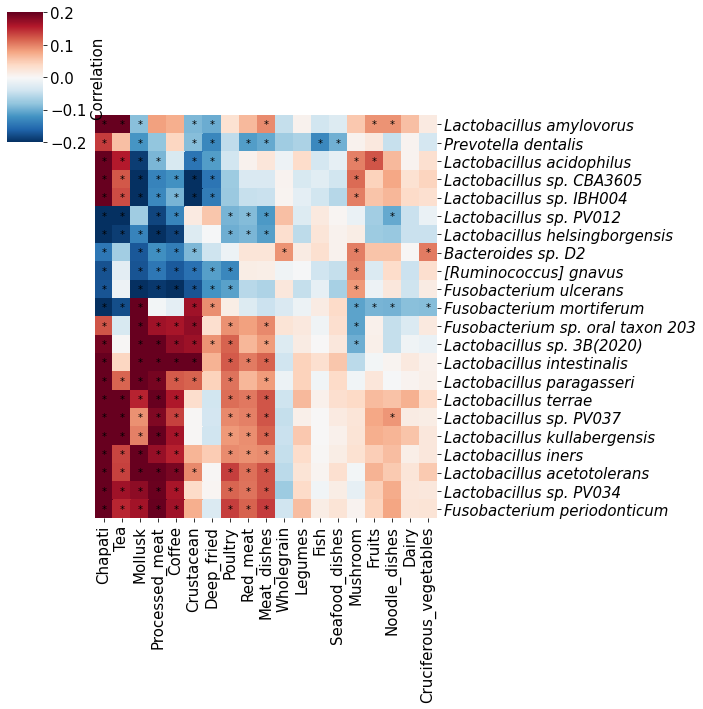

In [34]:
filtered_significance_matrix_scfa = significant_matrix_scfa.loc[filtered_species_scfa.index, filtered_species_scfa.columns]
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)


plt.figure(figsize=(20, 10))
ax = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=True)

ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)

row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new position in the clustered heatmap
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.rc('font', size=15)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=15)

plt.show()

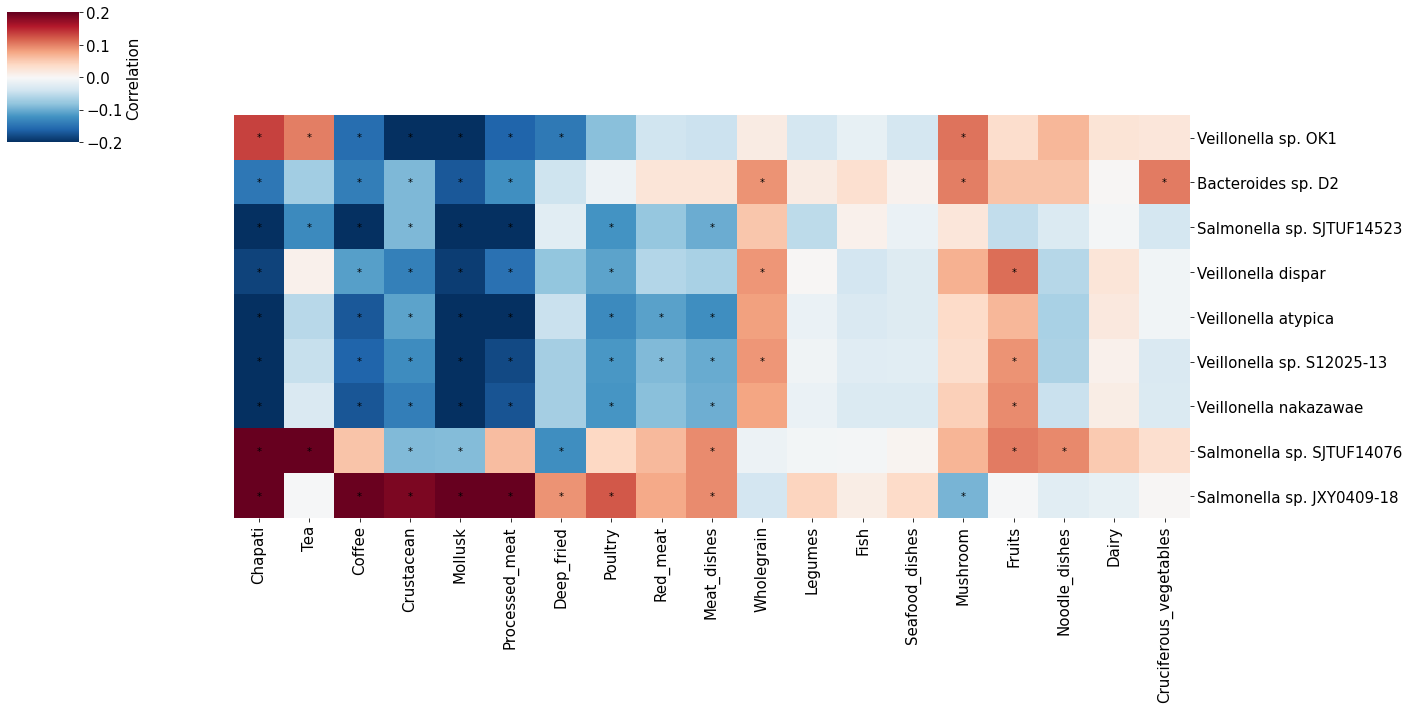

In [127]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Custom column order
custom_order = [
    'Chapati', 'Tea', 'Coffee', 'Crustacean', 'Mollusk', 'Processed_meat',
    'Deep_fried', 'Poultry', 'Red_meat', 'Meat_dishes', 'Wholegrain',
    'Legumes', 'Fish', 'Seafood_dishes', 'Mushroom', 'Fruits',
    'Noodle_dishes', 'Dairy', 'Cruciferous_vegetables'
]

# Reorder the data and significance matrix according to the custom order
filtered_species_scfa = filtered_species_scfa[custom_order]
filtered_significance_matrix_scfa = filtered_significance_matrix_scfa[custom_order]

# Clip the correlations as before
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Create a clustermap with row clustering only
cluster_grid = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=False, figsize=(20, 10))

# Hide the dendrogram for columns
cluster_grid.ax_col_dendrogram.set_visible(False)
cluster_grid.ax_row_dendrogram.set_visible(False)


# Retrieve the new order of rows after clustering
row_order = cluster_grid.dendrogram_row.reordered_ind

# Annotating with significance marks, taking into account the new row order
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new row position in the clustered heatmap
        new_i = row_order.index(i)
        cluster_grid.ax_heatmap.text(j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

plt.show()


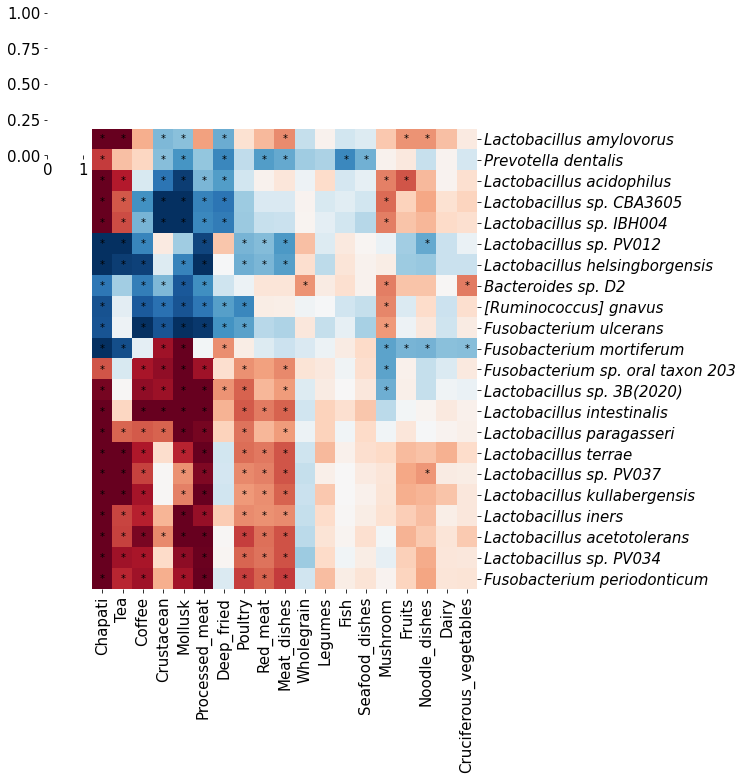

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Custom column order
custom_order = [
    'Chapati', 'Tea', 'Coffee', 'Crustacean', 'Mollusk', 'Processed_meat',
    'Deep_fried', 'Poultry', 'Red_meat', 'Meat_dishes', 'Wholegrain',
    'Legumes', 'Fish', 'Seafood_dishes', 'Mushroom', 'Fruits',
    'Noodle_dishes', 'Dairy', 'Cruciferous_vegetables'
]

# Reorder the data and significance matrix according to the custom order
filtered_species_scfa = filtered_species_scfa[custom_order]
filtered_significance_matrix_scfa = filtered_significance_matrix_scfa[custom_order]

# Clip the correlations as before
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Create a clustermap with row clustering only, no color bar, trying to make it more square-like
cluster_grid = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar=False, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=False, figsize=(10, 11), dendrogram_ratio=(.1, .2))

# Hide the dendrogram for columns
cluster_grid.ax_col_dendrogram.set_visible(False)
cluster_grid.ax_row_dendrogram.set_visible(False)

# Retrieve the new order of rows after clustering
row_order = cluster_grid.dendrogram_row.reordered_ind

# Annotating with significance marks, taking into account the new row order
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new row position in the clustered heatmap
        new_i = row_order.index(i)
        cluster_grid.ax_heatmap.text(j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in cluster_grid.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
cluster_grid.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.show()
